# Importing required libraries for the project

In [218]:
from pyspark.sql.types import StringType, IntegerType, FloatType, TimestampType
from pyspark.sql import functions as F
from pyspark.sql import SparkSession
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import time
import json
import numpy as np 
%matplotlib inline

# Creating spark session

In [219]:
spark = SparkSession.builder \
    .appName("DDA_final_project") \
    .master("local[4]") \
    .config("spark.sql.shuffle.partitions", "12") \
    .config("spark.executor.memory", "4g") \
    .config("spark.executor.cores", "4") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .getOrCreate()

In [220]:
exec_time = {}

# Defining all forms of nulls/missing values

In [221]:
def normalize_nulls(sdf):
    for col_name in sdf.columns:
        sdf = sdf.withColumn(
            col_name,
            F.when(
                F.trim(F.col(col_name).cast("string")).isin("", "nan", "NaN", "None", "none"),
                F.lit(None)
            ).otherwise(F.col(col_name))
        )
    return sdf

# Data set definition card

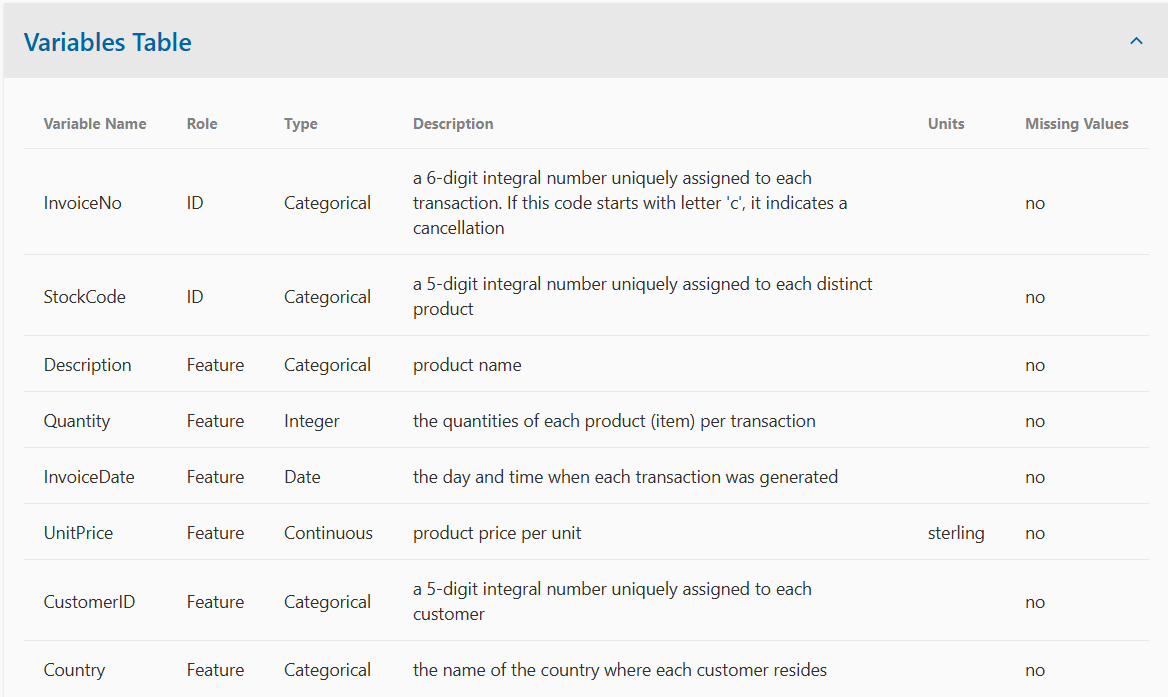

## Reading the data From HDFS

In [222]:
df1 = spark.read.parquet("hdfs://localhost:9005/user/yuuchan/bronze/sheet1/online_retail_sheet1.parquet")
df1  = normalize_nulls(df1)

In [223]:
df2 = spark.read.parquet("hdfs://localhost:9005/user/yuuchan/bronze/sheet2/online_retail_sheet2.parquet")
df2  = normalize_nulls(df2)

# Append/Union 2 pyspark data frames into single data frame called "df"

In [224]:
df = df1.union(df2)

# Viewing the first 10 rows of the combined data frame

In [225]:
df.show(10)

+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|C498280|    20728| LUNCH BAG CARS BLUE|      -1|2010-02-17 16:22:00| 1.45|    17511.0|United Kingdom|
|C498280|    22086|PAPER CHAIN KIT 5...|      -2|2010-02-17 16:22:00| 2.55|    17511.0|United Kingdom|
|C498280|    22310|KNITTED MUG COSY ...|      -1|2010-02-17 16:22:00| 1.45|    17511.0|United Kingdom|
|C498280|    10138|ASSORTED COLOUR J...|      -1|2010-02-17 16:22:00| 0.42|    17511.0|United Kingdom|
|C498280|    22127|PARTY CONES CARNI...|      -1|2010-02-17 16:22:00| 1.06|    17511.0|United Kingdom|
|C498280|    22130|PARTY CONE CHRIST...|      -1|2010-02-17 16:22:00| 0.72|    17511.0|United Kingdom|
|C498280|    35832|WOOLLY HAT SOCK G...|      -1|2010-02-17 16:22:00| 4.6

# Viewing the last 10 rows of the combined data frame

In [226]:
df.orderBy(F.monotonically_increasing_id(), ascending=False).limit(10).show()

+-------+---------+--------------------+--------+-------------------+-----+-----------+-------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+-------+
| 581587|     POST|             POSTAGE|       1|2011-12-09 12:50:00| 18.0|    12680.0| France|
| 581587|    22138|BAKING SET 9 PIEC...|       3|2011-12-09 12:50:00| 4.95|    12680.0| France|
| 581587|    23255|CHILDRENS CUTLERY...|       4|2011-12-09 12:50:00| 4.15|    12680.0| France|
| 581587|    23254|CHILDRENS CUTLERY...|       4|2011-12-09 12:50:00| 4.15|    12680.0| France|
| 581587|    22899|CHILDREN'S APRON ...|       6|2011-12-09 12:50:00|  2.1|    12680.0| France|
| 581587|    22613|PACK OF 20 SPACEB...|      12|2011-12-09 12:50:00| 0.85|    12680.0| France|
| 581587|    23256|CHILDRENS CUTLERY...|       4|2011-12-09 12:50:00| 4.15|    12680.0| France|
| 581587|    22629| SPACEBOY LUNCH BOX |

# Viewing the schema/structure of the combined data frame

In [227]:
df.printSchema()

root
 |-- Invoice: string (nullable = true)
 |-- StockCode: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: double (nullable = true)
 |-- Customer ID: double (nullable = true)
 |-- Country: string (nullable = true)



# Viewing the number of missing values/nulls in each column in the combined data frame

In [228]:
null_counts = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
null_counts.show()

+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|Invoice|StockCode|Description|Quantity|InvoiceDate|Price|Customer ID|Country|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+
|      0|        0|       4382|       0|          0|    0|     243007|      0|
+-------+---------+-----------+--------+-----------+-----+-----------+-------+



# Viewing the number of missing values/nulls in entire the combined data frame

In [229]:
total_nulls = null_counts.select(sum([F.col(c) for c in df.columns])).collect()[0][0]
print(f"Total Missing Values: {total_nulls}")

Total Missing Values: 247389


# Data cleaning and preprocessing

## (1) Cleaning "StockCode" column
### a) Keeping only the first 5 numbers of records/rows which start with numbers

### b) if the record doesn't start with a number then assign it as null

In [230]:
df = df.withColumn("StockCode",
    F.when(F.col("StockCode").rlike("^[0-9]"), F.regexp_extract(F.col("StockCode"), r"(\d{5})", 1))
    .otherwise(None)
)

### c) calculate the percentage of rows with null/missing value in this column to the total number of rows in the data set (or total number of rows in this column, as they are equal) then drop all of nulls/missing values in this column only (not entire data set)

In [231]:
total_count = df.count()
null_stock_count = df.filter(F.col("StockCode").isNull()).count()
print(f"StockCode Null Percentage: {(null_stock_count/total_count)*100:.2f}%")
df = df.dropna(subset=["StockCode"])

StockCode Null Percentage: 0.57%


## (2) Cleaning "Description" column

### a) Defining junk values to be removed from Description columns as they don't represent products names

In [232]:
junk_values = [
    "21494", "22719", "22467", "20713", "?", "??", "???", "????", "?missing",
    "?? missing", "???missing", "????missing", "? sold as sets?", "?sold as sets?",
    "?lost", "???lost", "????damages????", "?display?", "?sold individually?"
]

### b) assigning them as nulls/missing values in the Description column

In [233]:
df = df.withColumn("Description", F.when(F.col("Description").isin(junk_values), None).otherwise(F.col("Description")))

### c) Correcting miss-written product names
#### ex: "*Boombox Ipod Classic" => "Boombox Ipod Classic"

In [234]:
df = df.withColumn("Description", F.regexp_replace(F.col("Description"), r"^\*", ""))

### d) calculate the percentage of null rows in this column only to the total number of rows in the data set (or in the column as they are the same) then drop nulls in this column (not nulls in the entire data set)

In [235]:
null_desc_count = df.filter(F.col("Description").isNull()).count()
print(f"Description Null Percentage: {(null_desc_count/df.count())*100:.2f}%")
df = df.dropna(subset=["Description"])

Description Null Percentage: 0.42%


## (3) Cleaning "Quantity" column

### Converting Quantity negative values into positive values through taking absolute value to the negative Quantity value

In [236]:
df = df.withColumn("Quantity", F.abs(F.col("Quantity")))

## (4) Cleaning "Price" column

### a) Converting negative unit price rows values into positive values through taking absolute value to the negative unit price value

In [237]:
df = df.withColumn("Price", F.abs(F.col("Price")))

### b) replacing the rows of unit price value 0 with lowest positive value in the same "Price" column

In [238]:
min_positive_price = df.filter(F.col("Price") > 0).agg(F.min("Price")).collect()[0][0]
df = df.withColumn("Price", F.when(F.col("Price") == 0, min_positive_price).otherwise(F.col("Price")))

## (5) Cleaning "Customer ID" column

### a) Replacing each null/missing value in the "Customer ID" column with 0 value and storing result in a data frame called "df_all" to be used with analysis not related to customers

In [239]:
df_all = df.fillna({"Customer ID": 0})

In [240]:
df_all.cache()
df_all.count()

1056842

### b) Dropping all records with nulls/missing values in column "Customer ID" and storing resul in a data frame called "df_customer_id" to be used with customer analysis

In [241]:
df_customer_id = df.dropna(subset=["Customer ID"])

## (6) Duplicated rows detection and dropping

### a) Viewing total number of duplicated records in data frame "df_all" and dropping them

In [242]:
dup_all = df_all.count() - df_all.dropDuplicates().count()
print(f"Duplicates in df_all: {dup_all}")
df_all = df_all.dropDuplicates()

Duplicates in df_all: 34290


### b) Viewing total number of duplicated records in data frame "df_customer_id" and dropping them

In [243]:
dup_cust = df_customer_id.count() - df_customer_id.dropDuplicates().count()
print(f"Duplicates in df_customer_id: {dup_cust}")
df_customer_id = df_customer_id.dropDuplicates()

Duplicates in df_customer_id: 26494


## (7) Adjusting data types of each column in each of the 2 pyspark data frames "df_all" and "df_customer_id"

In [244]:
def cast_columns(target_df):
    return target_df.withColumn("Invoice", F.col("Invoice").cast(StringType())) \
                    .withColumn("StockCode", F.col("StockCode").cast(IntegerType())) \
                    .withColumn("Description", F.col("Description").cast(StringType())) \
                    .withColumn("Quantity", F.col("Quantity").cast(IntegerType())) \
                    .withColumn("InvoiceDate", F.col("InvoiceDate").cast(TimestampType())) \
                    .withColumn("Price", F.col("Price").cast(FloatType())) \
                    .withColumn("Customer ID", F.col("Customer ID").cast(IntegerType())) \
                    .withColumn("Country", F.col("Country").cast(StringType()))

df_all = cast_columns(df_all)
df_customer_id = cast_columns(df_customer_id)

## Saving 2 cleaned/preprocessed data sets to the local disk

In [245]:
# df_all.toPandas().to_csv("df_all.csv", index=False)
# files.download("df_all.csv")
df_all.write.mode("overwrite").parquet("hdfs://localhost:9005/user/yuuchan/silver/df_all.parquet")

In [246]:
# df_customer_id.toPandas().to_csv("df_customer_id.csv", index=False)
# files.download("df_customer_id.csv")
df_customer_id.write.mode("overwrite").parquet("hdfs://localhost:9005/user/yuuchan/silver/df_customer_id.parquet")

# EDA (Exploratory Data Analysis)

## (1) Percentage of completed invoices vs Percentage of Cancelled invoices

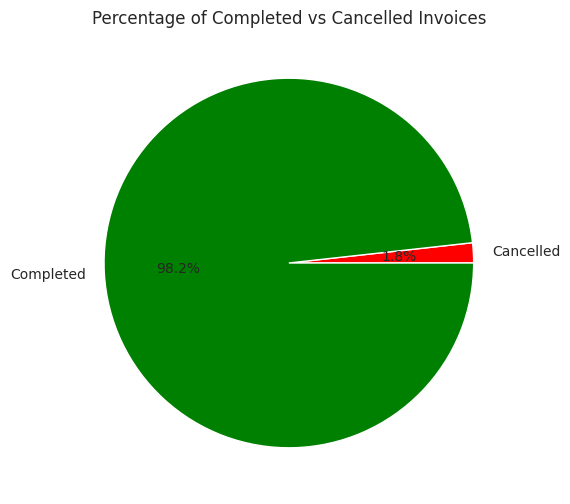

In [247]:
status_df = df_all.withColumn("Status", F.when(F.col("Invoice").startswith("C"), "Cancelled").otherwise("Completed"))
status_df = status_df.repartition(8, "Status")
status_counts_execution_time = time.time()
status_counts = status_df.groupBy("Status").count().toPandas()
exec_time["status_counts"] = time.time() - status_counts_execution_time

plt.figure(figsize=(8, 6))
plt.pie(status_counts['count'], labels=status_counts['Status'], autopct='%1.1f%%',
        colors=['red' if x == 'Cancelled' else 'green' for x in status_counts['Status']])
plt.title("Percentage of Completed vs Cancelled Invoices")
plt.show()

In [248]:
print("Execution Times:")
for key, value in exec_time.items():
    print(f"{key}: {value:.4f} seconds")

Execution Times:
status_counts: 0.9268 seconds


In [249]:
df_all = df_all.repartition(8, "StockCode")
description_map_execution_time = time.time()
description_map = df_all.select("StockCode", "Description").distinct() \
                        .groupBy("StockCode").agg(F.first("Description").alias("ProductDescription"))
exec_time["description_map"] = time.time() - description_map_execution_time

## Function to add value of y-axis of point to the visual

In [250]:
def add_labels(ax):
    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2f}' if p.get_height() > 100 else f'{int(p.get_height())}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha = 'center', va = 'center',
                    xytext = (0, 9),
                    textcoords = 'offset points',
                    fontsize=9)

## (2) Top 10 most sold products according to quantity

/tmp/ipykernel_123695/1692904990.py:11: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=top_sold_with_desc, x="StockCode", y="TotalQuantity", palette="viridis")


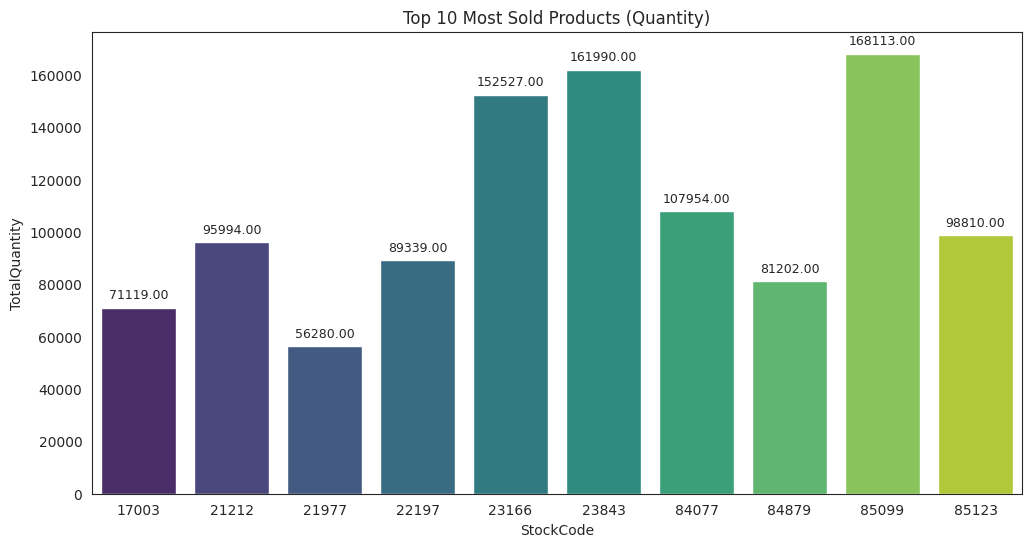

In [251]:
df_all = df_all.repartition(8, "StockCode")
top_sold_data_execution_time = time.time()
top_sold_data = df_all.groupBy("StockCode").agg(F.sum("Quantity").alias("TotalQuantity")) \
                      .orderBy(F.desc("TotalQuantity")).limit(10)

# Join with description map for the table
top_sold_with_desc = top_sold_data.join(description_map, "StockCode").toPandas()
exec_time["top_sold_data"] = time.time() - top_sold_data_execution_time

plt.figure(figsize=(12, 6))
ax1 = sns.barplot(data=top_sold_with_desc, x="StockCode", y="TotalQuantity", palette="viridis")
add_labels(ax1)
plt.title("Top 10 Most Sold Products (Quantity)")
plt.show()

## (3) Top 10 most popular products according to presence in different invoices

/tmp/ipykernel_123695/2161831008.py:22: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(data=pdf, x="StockCode", y="InvoiceCount", palette="magma")


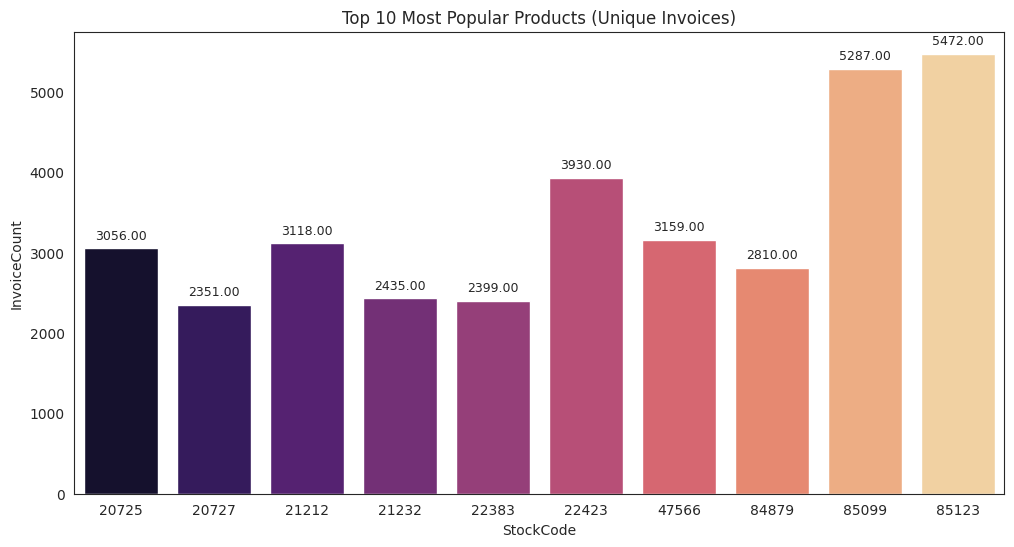

In [252]:
popular_data_execution_time = time.time()
sales = df_all.select("Invoice", "StockCode") \
    .filter(~F.col("Invoice").startswith("C")) \
    .repartition(8, "StockCode") 

popular_data = sales.groupBy("StockCode") \
    .agg(F.countDistinct("Invoice").alias("InvoiceCount"))

top10 = popular_data.orderBy(F.desc("InvoiceCount")).limit(10)

popular_with_desc = top10.join(
    F.broadcast(description_map.select("StockCode", F.col("ProductDescription").alias("Description"))),
    "StockCode",
    "left"
)


pdf = popular_with_desc.toPandas()
exec_time["popular_data"] = time.time() - popular_data_execution_time

plt.figure(figsize=(12,6))
ax2 = sns.barplot(data=pdf, x="StockCode", y="InvoiceCount", palette="magma")
add_labels(ax2)
plt.title("Top 10 Most Popular Products (Unique Invoices)")
plt.show()

## (4) Top 10 products according to sales

/tmp/ipykernel_123695/326551642.py:23: FutureWarning:                           

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_10_with_desc, x=top_10_with_desc["StockCode"].astype(str),


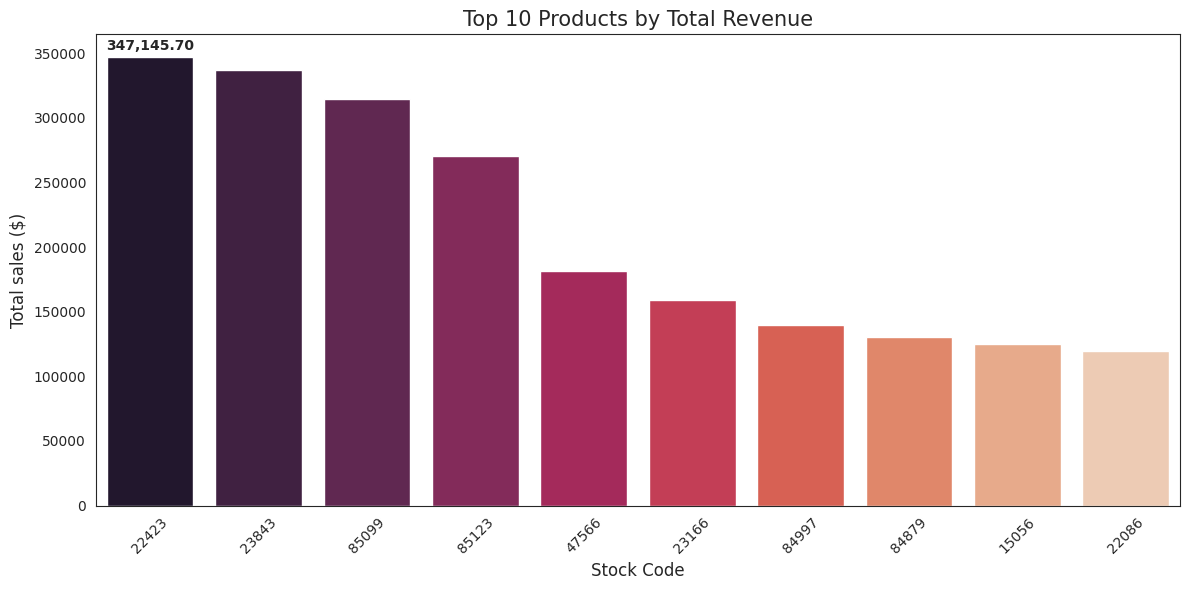

In [253]:
# 1. Calculate Revenue (Quantity * Price)
top_10_revenue_spark_execution_time = time.time()
df_all = df_all.withColumn("Revenue", F.col("Quantity") * F.col("Price"))

# 2. Group by StockCode and sum Revenue to get top 10
df_all = df_all.repartition(8, "StockCode")
top_10_revenue_spark = df_all.groupBy("StockCode") \
                             .agg(F.sum("Revenue").alias("TotalRevenue")) \
                             .orderBy(F.desc("TotalRevenue")) \
                             .limit(10)

# 3. Create a Description Lookup Table for these top 10
# (We drop duplicates to get one clean description per StockCode)
desc_lookup = df_all.select("StockCode", "Description").dropDuplicates(["StockCode"])
top_10_with_desc = top_10_revenue_spark.join(desc_lookup, on="StockCode", how="left") \
                                       .orderBy(F.desc("TotalRevenue")) \
                                       .toPandas()

exec_time["top_10_revenue_spark"] = time.time() - top_10_revenue_spark_execution_time

# --- Visual 1: Bar Chart ---
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=top_10_with_desc, x=top_10_with_desc["StockCode"].astype(str),
                 y="TotalRevenue", palette="rocket")

# Add the exact revenue values on top of each bar
ax.bar_label(ax.containers[0], fmt='{:,.2f}', padding=3, fontsize=10, fontweight='bold')

plt.title("Top 10 Products by Total Revenue", fontsize=15)
plt.xlabel("Stock Code", fontsize=12)
plt.ylabel("Total sales ($)", fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [254]:
print(top_10_with_desc[["StockCode", "Description", "TotalRevenue"]].to_string(index=False))

 StockCode                        Description  TotalRevenue
     22423           REGENCY CAKESTAND 3 TIER 347145.695833
     23843        PAPER CRAFT , LITTLE BIRDIE 336939.187641
     85099               JUMBO BAG STRAWBERRY 314120.127810
     85123 WHITE HANGING HEART T-LIGHT HOLDER 270575.458485
     47566             TEA TIME PARTY BUNTING 181752.629766
     23166     MEDIUM CERAMIC TOP STORAGE JAR 159180.554261
     84997  RED 3 PIECE MINI DOTS CUTLERY SET 139372.131432
     84879      ASSORTED COLOUR BIRD ORNAMENT 130116.834133
     15056             EDWARDIAN PARASOL PINK 124700.326524
     22086    PAPER CHAIN KIT 50'S CHRISTMAS  119221.988976


## (5) Total orders placed by top 10 countries in the data set

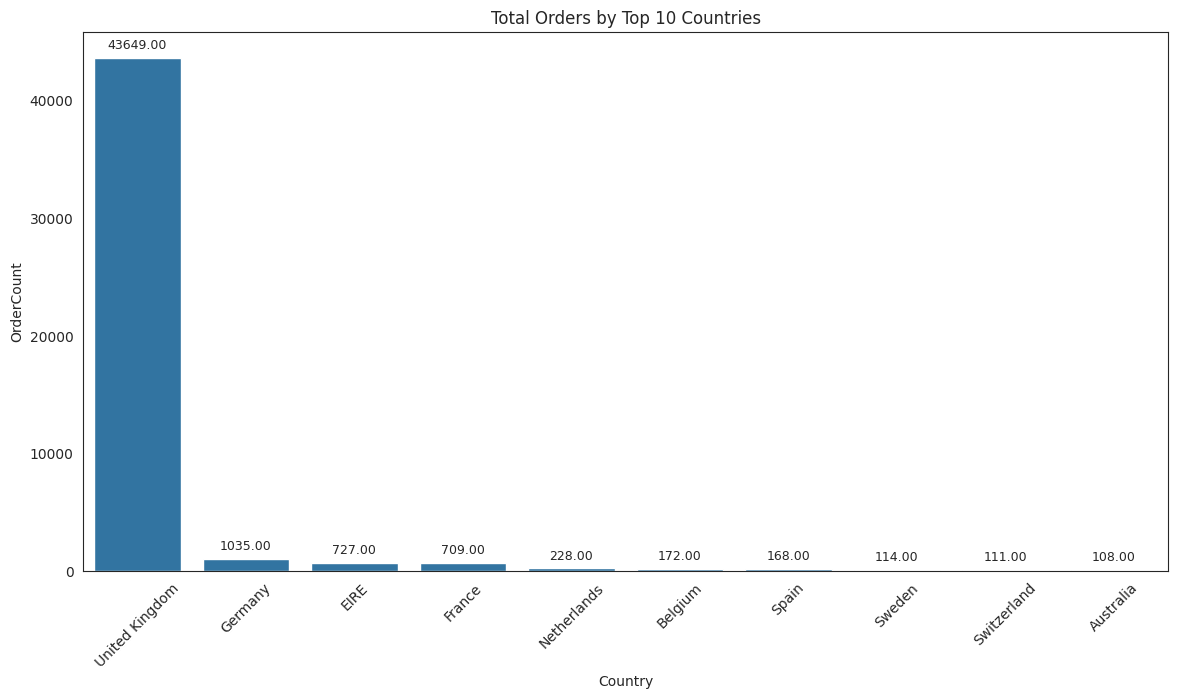

In [255]:
# Keep only needed columns + repartition by grouping key
country_orders_execution_time = time.time()
country_orders = (df_all
    .select("Country", "Invoice")  # Select only needed columns
    .filter(F.col("Country").isNotNull())  # Filter nulls early
    .groupBy("Country")
    .agg(F.countDistinct("Invoice").alias("OrderCount"))
    .orderBy(F.desc("OrderCount"))
    .limit(10)
    .toPandas())

exec_time["country_orders"] = time.time() - country_orders_execution_time
plt.figure(figsize=(14,7))
ax3 = sns.barplot(data=country_orders, x="Country", y="OrderCount")
add_labels(ax3)
plt.title("Total Orders by Top 10 Countries")
plt.xticks(rotation=45)
plt.show()

## (6) Total sales from top 10 countries in the data set

/tmp/ipykernel_123695/1539697138.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


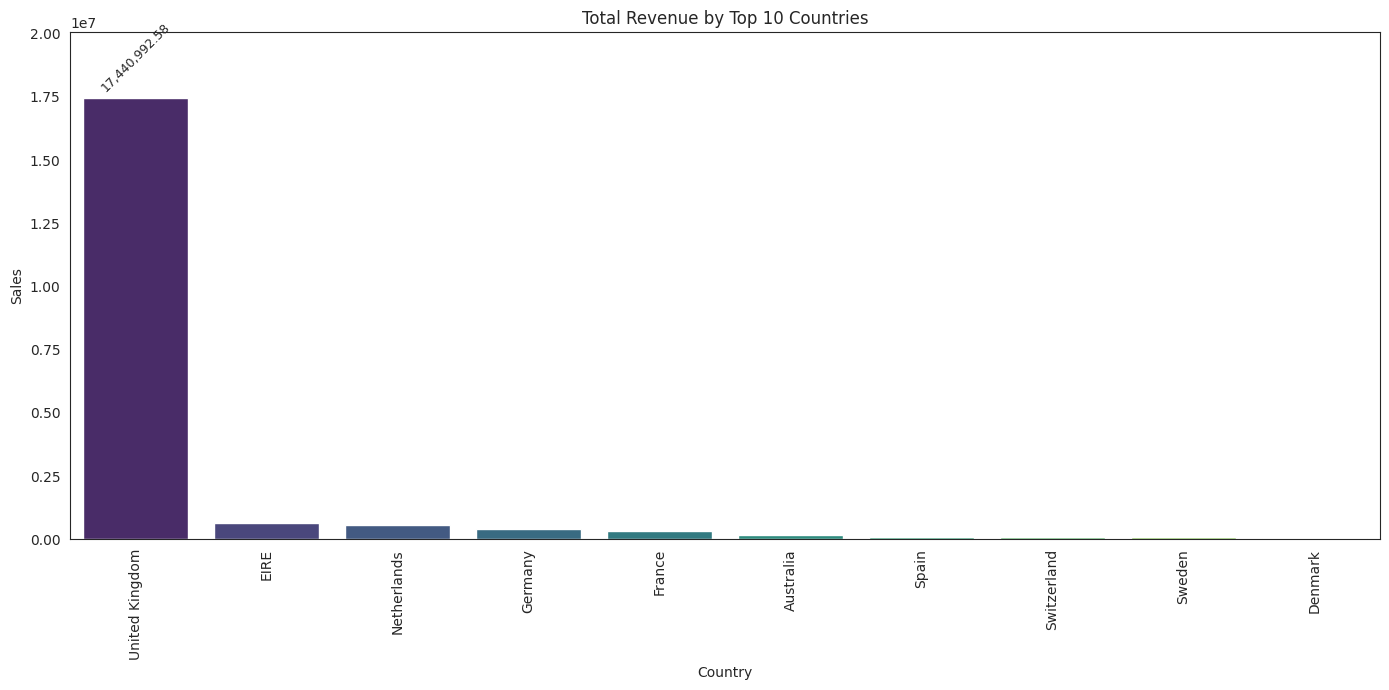

In [256]:
# Keep only needed columns + filter nulls
country_revenue_execution_time = time.time()
sales = df_all.select("Country", "Quantity", "Price") \
    .filter(F.col("Country").isNotNull()) \
    .repartition(8, "Country")

# Create revenue after pruning columns
sales = sales.withColumn(
    "Revenue",
    F.col("Quantity") * F.col("Price")
)

# Aggregate revenue by country
country_revenue = sales.groupBy("Country") \
    .agg(F.sum("Revenue").alias("TotalRevenue")) \
    .orderBy(F.desc("TotalRevenue")) \
    .limit(10)

# Only final small result to pandas
pdf = country_revenue.toPandas()
exec_time["country_revenue"] = time.time() - country_revenue_execution_time
# Plot
plt.figure(figsize=(14,7))
ax = sns.barplot(
    data=pdf,
    x="Country",
    y="TotalRevenue",
    palette="viridis"
)

ax.bar_label(
    ax.containers[0],
    fmt='{:,.2f}',
    padding=3,
    rotation=45,
    fontsize=9
)

plt.title("Total Revenue by Top 10 Countries")
plt.ylabel("Sales")
plt.xlabel("Country")
plt.xticks(rotation=90)
plt.ylim(0, pdf["TotalRevenue"].max() * 1.15)
plt.tight_layout()
plt.show()

## (7) Time-Series EDA

In [257]:
df_time = df_all.withColumn("Year", F.year("InvoiceDate")) \
                .withColumn("Month", F.month("InvoiceDate")) \
                .withColumn("Quarter", F.quarter("InvoiceDate"))

### a) Yearly sales trend

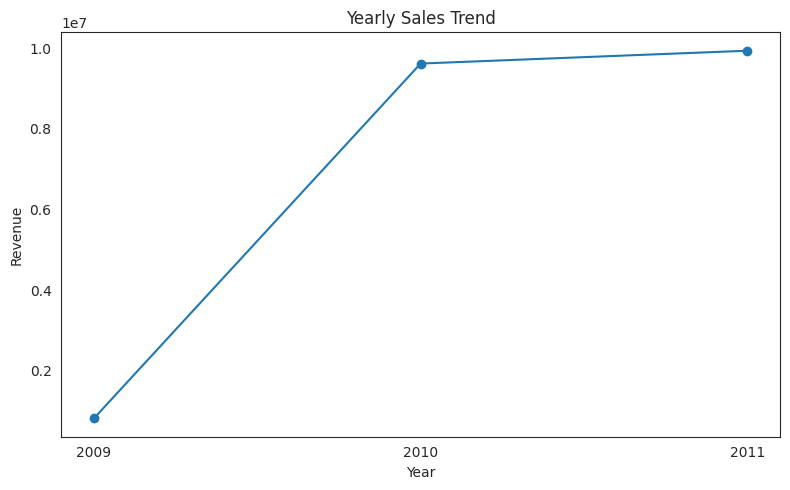

In [258]:
# Keep only needed columns + repartition by Year
yearly_sales_execution_time = time.time()
sales_time = df_time.select("Year", "Revenue") \
    .filter(F.col("Year").isNotNull()) \
    .repartition(8, "Year")

# Aggregate yearly sales
yearly_sales = sales_time.groupBy("Year") \
    .agg(F.sum("Revenue").alias("Sales")) \
    .orderBy("Year")

# Only final small result to pandas
pdf = yearly_sales.toPandas()
exec_time["yearly_sales"] = time.time() - yearly_sales_execution_time
# Plot
plt.figure(figsize=(8,5))
plt.plot(
    pdf["Year"].astype(str),
    pdf["Sales"],
    marker="o"
)

plt.title("Yearly Sales Trend")
plt.ylabel("Revenue")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [259]:
df_all = df_all.withColumn("Revenue", F.col("Quantity") * F.col("Price"))
df_time = df_all.withColumn("Year", F.year("InvoiceDate")) \
                .withColumn("Month", F.month("InvoiceDate")) \
                .withColumn("Quarter", F.quarter("InvoiceDate"))

### b) Montly sales trend for year 2010

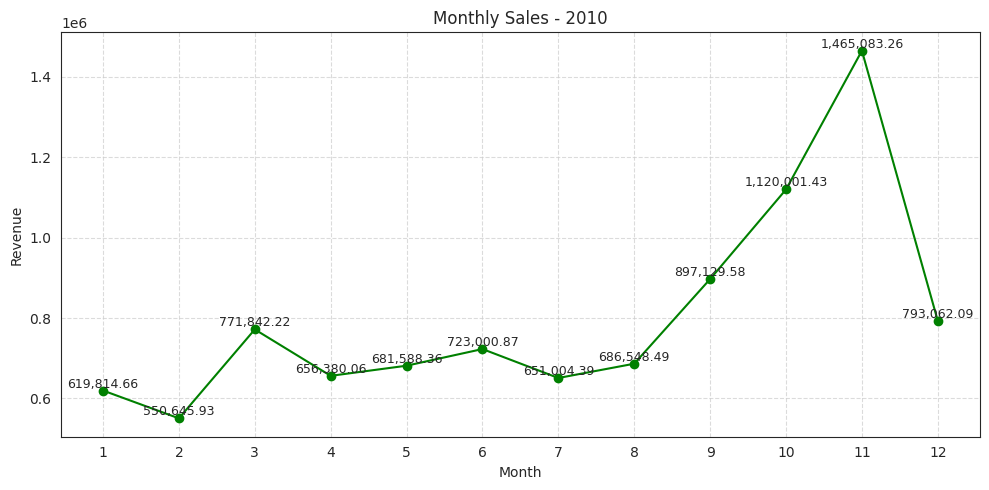

In [260]:

data_2010_m_execution_time = time.time()

sales_2010 = df_time.select("Year", "Month", "Revenue") \
    .filter(F.col("Year") == 2010) \
    .filter(F.col("Month").isNotNull()) \
    .repartition(8, "Month")

# Aggregate monthly revenue
data_2010_m = sales_2010.groupBy("Month") \
    .agg(F.sum("Revenue").alias("Sales")) \
    .orderBy("Month")

# Only 12 rows to pandas
pdf = data_2010_m.toPandas()
exec_time["data_2010_m"] = time.time() - data_2010_m_execution_time
# Plot
plt.figure(figsize=(10,5))
plt.plot(
    pdf["Month"],
    pdf["Sales"],
    marker="o",
    linestyle="-",
    color="green"
)

# Labels
for x, y in zip(pdf["Month"], pdf["Sales"]):
    plt.text(
        x,
        y,
        f"{y:,.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Monthly Sales - 2010")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### c) Quarterly sales trend for year 2010

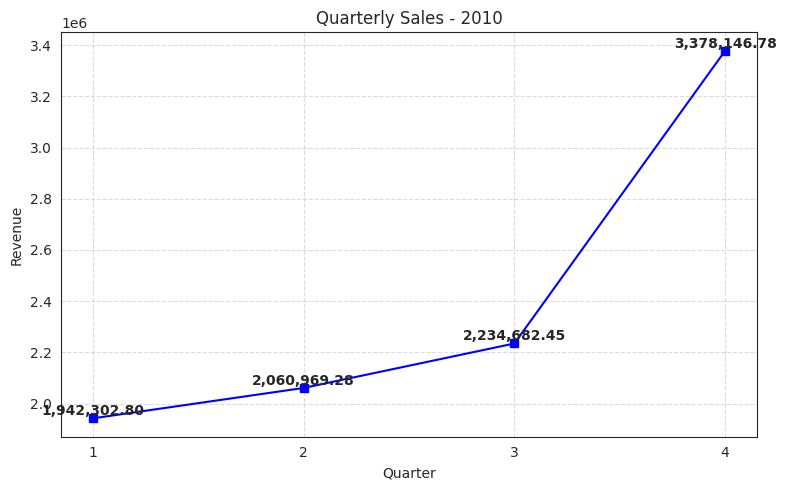

In [261]:

data_2010_q_execution_time = time.time()


sales_2010_q = df_time.select("Year", "Quarter", "Revenue") \
    .filter(F.col("Year") == 2010) \
    .filter(F.col("Quarter").isNotNull()) \
    .repartition(8, "Quarter")

# Aggregate quarterly revenue
data_2010_q = sales_2010_q.groupBy("Quarter") \
    .agg(F.sum("Revenue").alias("Sales")) \
    .orderBy("Quarter")

# Only 4 rows to pandas
pdf = data_2010_q.toPandas()
exec_time["data_2010_q"] = time.time() - data_2010_q_execution_time
# Plot
plt.figure(figsize=(8,5))
plt.plot(
    pdf["Quarter"],
    pdf["Sales"],
    marker="s",
    linestyle="-",
    color="blue"
)

# Labels
for x, y in zip(pdf["Quarter"], pdf["Sales"]):
    plt.text(
        x,
        y,
        f"{y:,.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Quarterly Sales - 2010")
plt.xticks([1,2,3,4])
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### d) Montly sales trend for year 2011

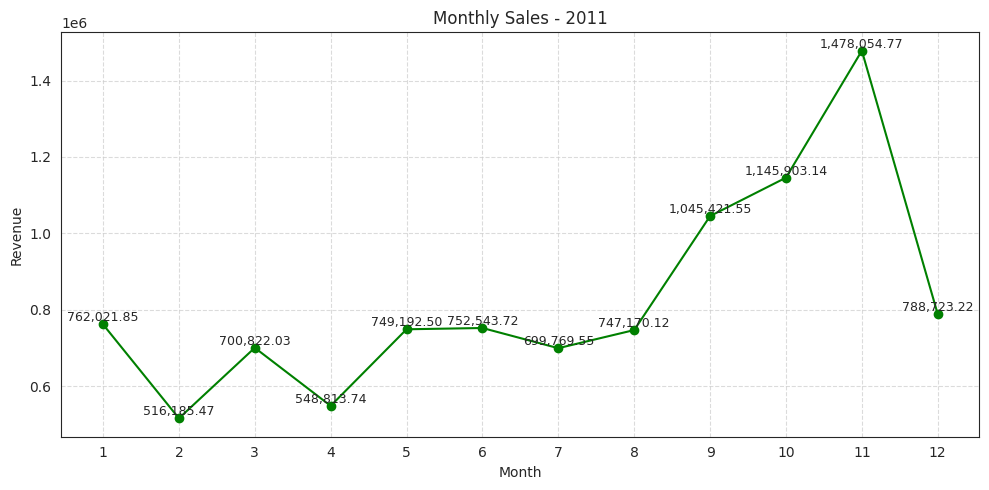

In [262]:
data_2011_m_execution_time = time.time()
sales_2011 = df_time.select("Year", "Month", "Revenue") \
    .filter(F.col("Year") == 2011) \
    .filter(F.col("Month").isNotNull()) \
    .repartition(8, "Month")

# Aggregate monthly revenue
data_2011_m = sales_2011.groupBy("Month") \
    .agg(F.sum("Revenue").alias("Sales")) \
    .orderBy("Month")

# Only final small result to pandas
pdf = data_2011_m.toPandas()
exec_time["data_2011_m"] = time.time() - data_2011_m_execution_time
# Plot
plt.figure(figsize=(10,5))
plt.plot(
    pdf["Month"],
    pdf["Sales"],
    marker="o",
    linestyle="-",
    color="green"
)

# Labels
for x, y in zip(pdf["Month"], pdf["Sales"]):
    plt.text(
        x,
        y,
        f"{y:,.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.title("Monthly Sales - 2011")
plt.xticks(range(1,13))
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

### e) Quarterly sales trend for year 2011

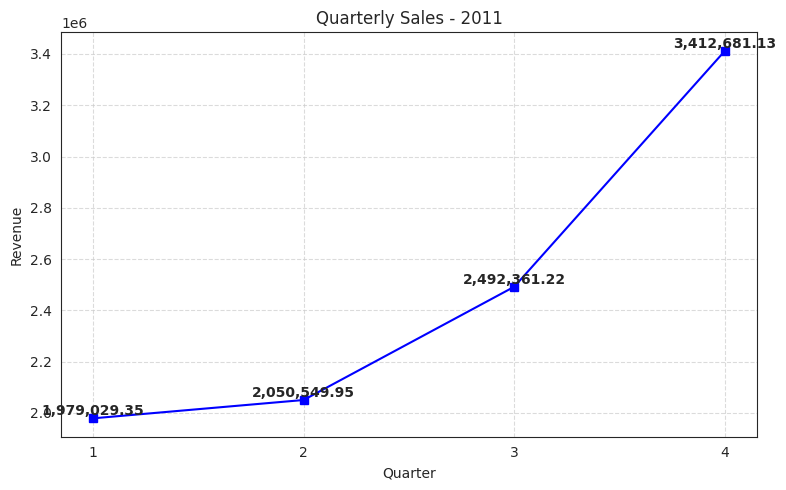

In [263]:
data_2011_q_execution_time = time.time()
sales_2011_q = df_time.select("Year", "Quarter", "Revenue") \
    .filter(F.col("Year") == 2011) \
    .filter(F.col("Quarter").isNotNull()) \
    .repartition(8, "Quarter")

# Aggregate quarterly revenue
data_2011_q = sales_2011_q.groupBy("Quarter") \
    .agg(F.sum("Revenue").alias("Sales")) \
    .orderBy("Quarter")

# Only 4 rows to pandas
pdf = data_2011_q.toPandas()
exec_time["data_2011_q"] = time.time() - data_2011_q_execution_time

# Plot
plt.figure(figsize=(8,5))
plt.plot(
    pdf["Quarter"],
    pdf["Sales"],
    marker="s",
    linestyle="-",
    color="blue"
)

# Labels
for x, y in zip(pdf["Quarter"], pdf["Sales"]):
    plt.text(
        x,
        y,
        f"{y:,.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Quarterly Sales - 2011")
plt.xticks([1,2,3,4])
plt.xlabel("Quarter")
plt.ylabel("Revenue")
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

## (8) Customer EDA

### a) Top 10 customers according to spending

/tmp/ipykernel_123695/2360813583.py:13: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax4 = sns.barplot(data=top_cust, x="Customer ID", y="TotalSpent", palette="coolwarm")


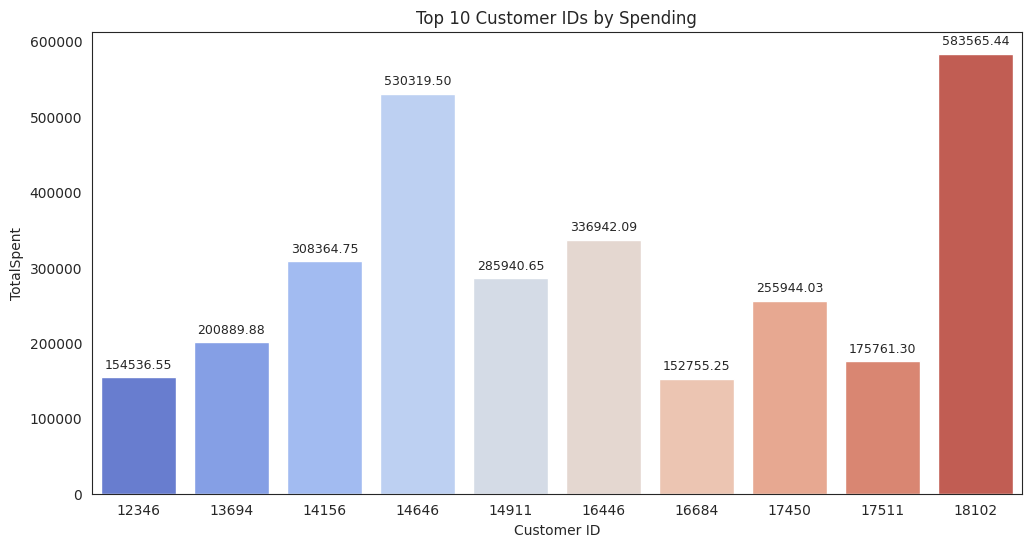

In [264]:
top_cust_df = (
    df_customer_id
    .withColumn("Revenue", F.col("Quantity") * F.col("Price"))
    .groupBy("Customer ID")
    .agg(F.sum("Revenue").alias("TotalSpent"))
    .orderBy(F.col("TotalSpent").desc())
    .limit(10)
)

top_cust = top_cust_df.toPandas()

plt.figure(figsize=(12, 6))
ax4 = sns.barplot(data=top_cust, x="Customer ID", y="TotalSpent", palette="coolwarm")
add_labels(ax4)
plt.title("Top 10 Customer IDs by Spending")
plt.show()

### b) top 5 visiting customers according to number of invoices

/tmp/ipykernel_123695/2513591149.py:15: FutureWarning:                          

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=top_5_frequent,


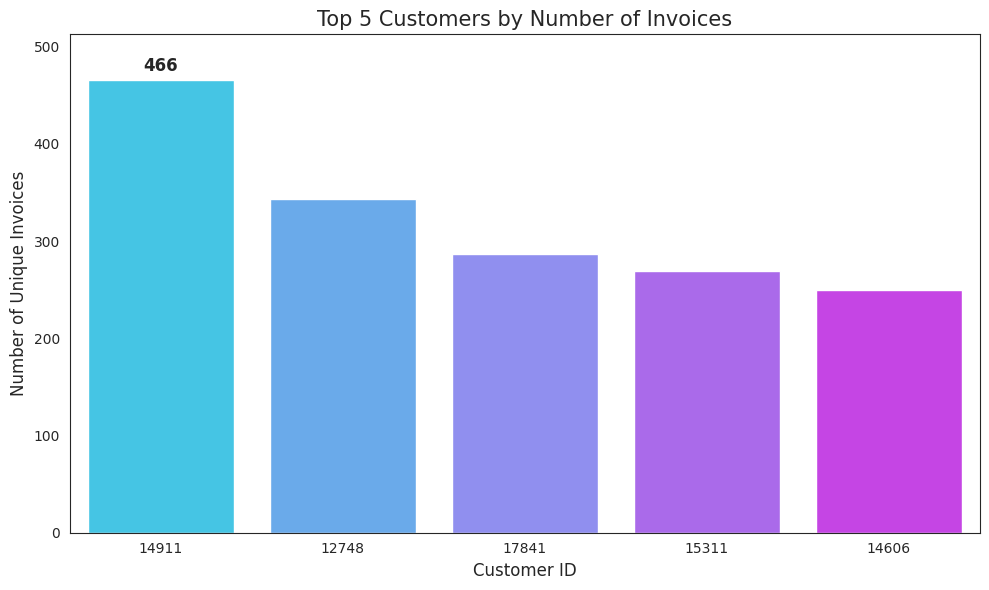

In [265]:
# 1. Group by Customer ID and count UNIQUE invoices
top_5_frequent_execution_time = time.time()
top_5_frequent = (df_customer_id
    .groupBy("Customer ID")
    .agg(F.countDistinct("Invoice").alias("InvoiceCount"))
    .orderBy(F.desc("InvoiceCount"))
    .limit(5)
    .toPandas())
exec_time["top_5_frequent"] = time.time() - top_5_frequent_execution_time
# 2. Create the Visual
plt.figure(figsize=(10, 6))
sns.set_style("white") # Clean background

# Note: Converting Customer ID to string so the x-axis doesn't treat them as continuous numbers
ax = sns.barplot(data=top_5_frequent,
                 x=top_5_frequent["Customer ID"].astype(str),
                 y="InvoiceCount",
                 palette="cool")

# 3. Add the exact values on top of the bars
ax.bar_label(ax.containers[0], padding=3, fontsize=12, fontweight='bold')

# Formatting
plt.title("Top 5 Customers by Number of Invoices", fontsize=15)
plt.xlabel("Customer ID", fontsize=12)
plt.ylabel("Number of Unique Invoices", fontsize=12)
plt.ylim(0, top_5_frequent["InvoiceCount"].max() * 1.1) # Add space for labels

plt.tight_layout()
plt.show()

In [266]:
spark.stop()

In [267]:
# Optimized
print("Execution Times:")
for key, value in exec_time.items():
    print(f"{key}: {value:.4f} seconds")

Execution Times:
status_counts: 0.9268 seconds
description_map: 0.0071 seconds
top_sold_data: 1.9144 seconds
popular_data: 2.1143 seconds
top_10_revenue_spark: 1.6577 seconds
country_orders: 1.3819 seconds
country_revenue: 1.1256 seconds
yearly_sales: 1.3515 seconds
data_2010_m: 0.7692 seconds
data_2010_q: 0.8598 seconds
data_2011_m: 0.6703 seconds
data_2011_q: 0.7640 seconds
top_5_frequent: 1.5608 seconds


In [268]:
with open('non_optimized_times.json', 'r') as f:
    non_optimized_times = json.load(f)
    
print(non_optimized_times)

{'status_counts': 1.337092638015747, 'description_map': 0.013443708419799805, 'top_sold_data': 2.6150639057159424, 'popular_data': 2.325310707092285, 'top_10_revenue_spark': 1.9596354961395264, 'country_orders': 1.1849274635314941, 'country_revenue': 1.226569652557373, 'yearly_sales': 1.484588861465454, 'data_2010_m': 1.671064853668213, 'data_2010_q': 1.644120216369629, 'data_2011_m': 1.7650628089904785, 'data_2011_q': 0.9341583251953125, 'top_5_frequent': 1.2580561637878418}


In [269]:
optimized_times = exec_time

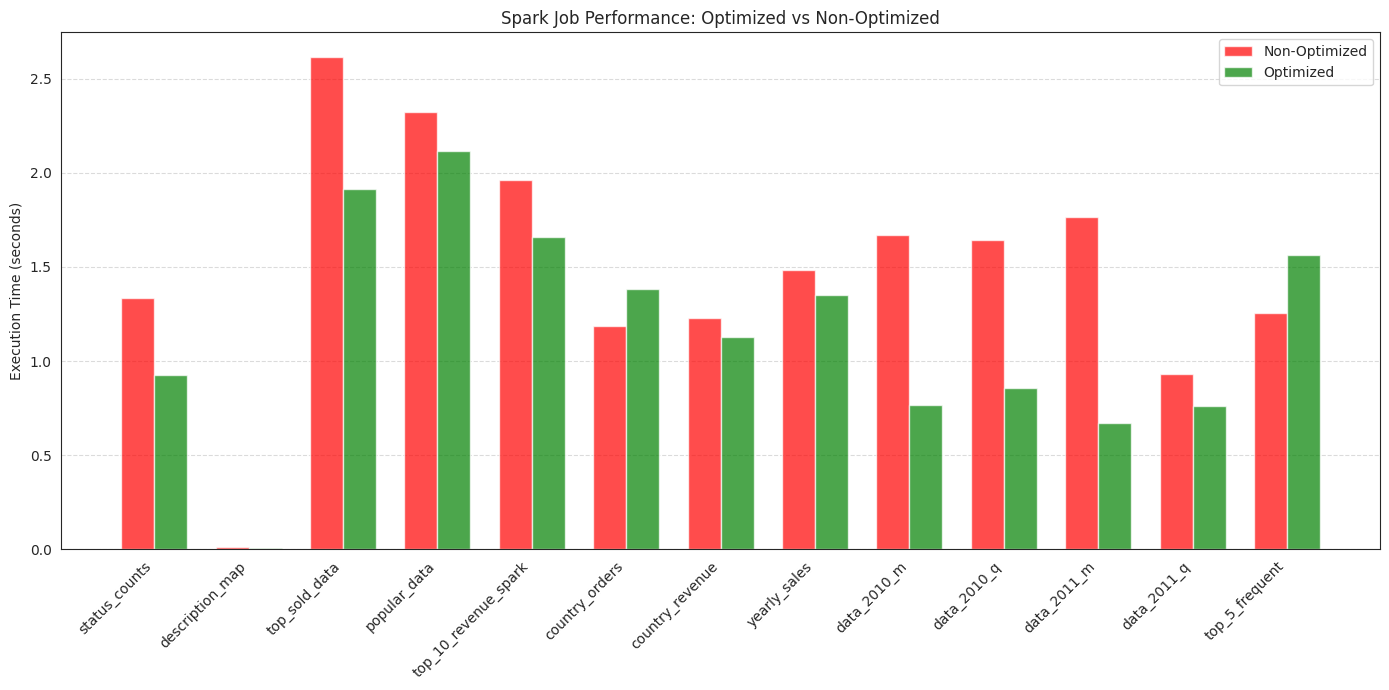

In [270]:
x = np.arange(len(exec_time))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 7))
rects1 = ax.bar(x - width/2, non_optimized_times.values(), width, label='Non-Optimized', color='red', alpha=0.7)
rects2 = ax.bar(x + width/2, optimized_times.values(), width, label='Optimized', color='green', alpha=0.7)

ax.set_ylabel('Execution Time (seconds)')
ax.set_title('Spark Job Performance: Optimized vs Non-Optimized')
ax.set_xticks(x)
ax.set_xticklabels(exec_time.keys(), rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

In [271]:
non_optimized_times.values()

dict_values([1.337092638015747, 0.013443708419799805, 2.6150639057159424, 2.325310707092285, 1.9596354961395264, 1.1849274635314941, 1.226569652557373, 1.484588861465454, 1.671064853668213, 1.644120216369629, 1.7650628089904785, 0.9341583251953125, 1.2580561637878418])

In [272]:
import json
with open('optimized_times.json', 'w') as f:
    json.dump(exec_time, f, indent=2)